In [ ]:
import sys

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import timedelta

sys.path.insert(0, str(Path.cwd().parent))
from scripts.dataloader.filter import *
from scripts.dataloader.parse_close import *


In [161]:
prices = pd.read_csv(Path.cwd().parent / "datasets" / "csv" / "NewClosePrice.csv")
price_columns = prices.columns
cols = [col for col in price_columns if 'SPY' in col]
price_columns.shape, cols, price_columns


((3131,),
 ['SPYT',
  'GSPY',
  'KSPY',
  'SPYM',
  'SPYG',
  'SPYD',
  'SPYV',
  'SPY',
  'SPYX',
  'SPYC',
  'SSPY',
  'DSPY',
  'ZSPY',
  'VSPY',
  'YSPY',
  'TSPY'],
 Index(['Date', 'SIXS', 'BDIV', 'SPDV', 'DMDV', 'EEMD', 'TRFM', 'ILOW', 'HIDV',
        'LOWV',
        ...
        'IBTA', 'AAA', 'AAAU', 'DBA', 'DBB', 'DBC', 'DGL', 'DBO', 'BKLN',
        'WCBR'],
       dtype='object', length=3131))

In [152]:
volumes = pd.read_csv(Path.cwd().parent / "datasets" / "csv" / "Volume.csv")
volumes = cosmetic_changes(volumes)
volumes = filter_business_dates(volumes)
volumes


,Date,SIXS,BDIV,SPDV,DMDV,EEMD,TRFM,ILOW,HIDV,LOWV,...,ZTRE,STNC,LRND,BSCU,INFR,CHGX,GRW,SHLD,UIVM,WCBR
0,2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,2025-12-24,2.301583e+05,1677.3946,66645.2487,NaN,NaN,2.252070e+05,2.103981e+06,1.284289e+05,5.634504e+05,...,1.661688e+04,3.338800e+02,6309.5500,7.087989e+06,409.7632,113699.7208,101901.541800,2.377322e+07,41888.087500,110187.365700
2500,2025-12-26,1.234969e+03,947830.9372,102663.3963,NaN,NaN,5.990710e+05,5.332227e+06,1.322992e+05,2.513265e+06,...,1.228938e+05,6.132850e+03,229226.0656,1.175920e+07,2519.2889,269144.0963,569018.823548,2.609650e+07,297430.449300,813831.590800
2501,2025-12-29,1.192071e+06,37318.0052,255470.8583,NaN,NaN,3.725592e+06,2.378058e+06,5.259524e+04,1.016938e+06,...,9.159870e+04,1.184894e+06,99639.7618,1.502459e+07,112422.4896,259151.8968,462016.861900,3.693749e+07,268183.258300,395913.305200
2502,2025-12-30,1.870296e+05,4524.5746,75046.0530,NaN,NaN,8.784358e+06,2.625912e+06,1.671163e+06,4.310199e+05,...,4.399449e+04,1.763316e+04,14126.8966,1.979544e+07,494.7907,521203.5323,274666.591100,4.027883e+07,192916.936667,330075.538210


In [153]:
first_business_days = pd.read_excel(Path.cwd().parent / "datasets" / "excel" / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [154]:
stats = pd.DataFrame()
stats["etfs"] = price_columns[1:]

pred_volumes = np.zeros(stats.shape[0])

start = first_business_days.iloc[0] - timedelta(days=30)
for month_date in first_business_days:
    end = month_date
    
    month_prices = get_first_day_month_returns(prices, None, startTime=start, endTime=end).drop('Date', axis=1)
    month_volumes = get_first_day_month_returns(prices, None, startTime=start, endTime=end).drop('Date', axis=1)
    
    start_price, end_price = month_prices.iloc[0], month_prices.iloc[-1]
    
    diff = (end_price - start_price).to_numpy()
    # diff = np.where(np.isnan(diff), -10_000, diff)
    stats["diff"] = np.round(diff, 1)
    
    # pct_price_change = np.where(start_price > 0, diff/start_price, 0)
    pct_price_change = np.divide(
        diff, 
        start_price, 
        out=np.zeros_like(start_price, dtype=float), 
        where=(start_price > 0)
    )
    stats["price_change"] = np.round(pct_volume_change, 2)
    
    total_volumes = month_volumes.sum().to_numpy()
    total_volumes = np.where(np.isnan(total_volumes), 0, total_volumes)
    stats["total_volume"] = np.round(total_volumes, 1)
    
    # pct_volume_change = np.where(pred_volumes > 0, (total_volumes - pred_volumes)/pred_volumes, 0)
    pct_volume_change = np.divide(
        (total_volumes - pred_volumes), 
        pred_volumes, 
        out=np.zeros_like(pred_volumes, dtype=float), 
        where=(pred_volumes > 0)
    )
    stats["volume_change"] = np.round(pct_volume_change, 2)
    
    # pct_change = np.divide(
    #     (total_volumes - pred_volumes), 
    #     pred_volumes, 
    #     out=np.zeros_like(pred_volumes, dtype=float), 
    #     where=(pred_volumes > 0)
    # )
    
    start = end
    pred_volumes = total_volumes
    
stats


,etfs,diff,price_change,total_volume,volume_change
0,SIXS,1.8,0.03,883.1,-0.18
1,BDIV,0.5,0.07,405.5,-0.19
2,SPDV,0.8,0.04,611.2,-0.19
3,DMDV,NaN,0.00,0.0,0.00
4,EEMD,NaN,0.00,0.0,0.00
...,...,...,...,...,...
3125,DBC,0.0,0.05,398.5,-0.17
3126,DGL,NaN,0.00,0.0,0.00
3127,DBO,-0.3,0.00,232.8,-0.18
3128,BKLN,0.0,0.05,376.6,-0.18


In [146]:
pred_volumes.shape, pct_volume_change


((3130,),
 array([-0.18359189, -0.18712575, -0.1937121 , ..., -0.18480202,
        -0.17709844, -0.22658321]))

In [147]:
ratio = (end_price-start_price)/start_price
ratio.sort_values()


APED   -0.476856
SPCY   -0.448410
IMRA   -0.326585
IMST   -0.309256
LAYS   -0.306847
          ...   
IFEU         NaN
AMCA         NaN
IBTA         NaN
AAAU         NaN
DGL          NaN
Length: 3130, dtype: float64

In [159]:
# stats.sort_values(by=["diff"], ascending=False).iloc[:50]
stats.sort_values(by=["price_change"], ascending=False).iloc[:50]
# stats.sort_values(by=["total_volume"], ascending=False).iloc[:50]
# stats.sort_values(by=["volume_change"], ascending=False).iloc[:50]


,etfs,diff,price_change,total_volume,volume_change
1369,AGIQ,-1.7,4.77,405.6,-0.19
2396,DADS,-1.8,4.73,359.6,-0.25
2915,TRUT,-1.3,4.68,477.1,-0.19
1363,SEPI,0.7,4.59,463.7,-0.17
785,TOT,0.0,4.58,377.0,-0.18
2382,DAK,0.2,4.57,472.9,-0.18
2627,BSCZ,0.3,4.56,372.2,-0.18
184,FRIZ,0.8,4.54,453.6,-0.18
997,BOBP,-0.5,4.54,459.2,-0.20
2159,WCPB,0.1,4.54,460.7,-0.18


In [71]:
stats.sort_values(by=["total_volume"], ascending=False).iloc[:30]


,etfs,diff,total_volume
1407,VGT,-43.7,13544.7
1478,IVV,0.2,12110.3
1338,SPY,0.0,12057.7
1411,VOO,0.1,11087.7
2671,QQQ,-12.8,10966.7
399,MDY,12.7,10557.5
1405,VUG,-11.0,8712.9
1531,IWF,-11.5,8479.1
1317,DIA,4.3,8431.0
1412,VOOG,-6.3,7890.0


In [168]:
import json
from pathlib import Path

import pandas as pd

# 1) Path to your JSON file
json_path = Path.cwd().parent / "datasets" / "monthly_filtration" / "top_etfs_by_month.json"

# 2) Output Excel file
output_xlsx = json_path.parent / "etf_values_by_date.xlsx"

# 4) Create full ETF universe
all_etfs = cols

if not all_etfs:
    raise ValueError("ETF universe is empty. Paste your ETF list into ALL_ETFS_TEXT.")


# 5) Load JSON: expected format is {date: [ETF1, ETF2, ...]}
with open(json_path, "r", encoding="utf-8") as f:
    top_etfs_by_month = json.load(f)

if not isinstance(top_etfs_by_month, dict):
    raise TypeError("JSON must be a dictionary: {date: [etf1, etf2, ...]}")


# 6) Optional safety check:
#    If JSON contains ETFs that are not in your master universe, add them.
all_etfs_set = set(all_etfs)

json_etfs = {
    str(ticker).strip().upper()
    for etf_list in top_etfs_by_month.values()
    for ticker in etf_list
}

missing_from_universe = sorted(json_etfs - all_etfs_set)

if missing_from_universe:
    print("Warning: these ETFs were in JSON but not in master ETF list.")
    print(missing_from_universe)

    # Add them so they are not lost
    all_etfs.extend(missing_from_universe)


# 7) Build dictionary:
#    key = date
#    value = dataframe with columns ['Key', 'Value']
etf_frames_by_date = {}

for date, selected_etfs in sorted(top_etfs_by_month.items()):
    selected_set = {
        str(ticker).strip().upper()
        for ticker in selected_etfs
    }

    df = pd.DataFrame({"Key": all_etfs})
    df["Value"] = df["Key"].isin(selected_set).astype(int)

    etf_frames_by_date[date] = df


# 8) Save to Excel:
#    each date becomes one sheet
with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    for date, df in etf_frames_by_date.items():
        sheet_name = str(date)[:31]  # Excel sheet name limit
        df.to_excel(writer, sheet_name=sheet_name, index=False)


print(f"Saved Excel file to: {output_xlsx}")
print(f"Number of dates saved: {len(etf_frames_by_date)}")
print(f"Number of ETFs per sheet: {len(all_etfs)}")

# Example check
first_date = next(iter(etf_frames_by_date))
print(f"\nExample dataframe for {first_date}:")
print(etf_frames_by_date[first_date].head())


ValueError: The truth value of a Index is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
from pathlib import Path

filepath = Path.cwd().parent / "datasets" / "monthly_filtration" / "monthly_etf_scores.csv"
df = pd.read_csv(filepath)
market_df = df[df["etf"]=='SPY']
market_df


,rebalance_date,window_start,window_end,etf,observations,start_price,end_price,price_diff,price_change,total_volume,...,volatility_ratio_vs_benchmark,risk_adjusted_return_benchmark,risk_adjusted_excess_return,total_volume_ratio_vs_benchmark,dollar_volume_ratio_vs_benchmark,aggregate_score,passed_base_filter,passed_benchmark_filter,selected,rank
1087,2016-02-01,2016-01-02,2016-02-01,SPY,19,170.786467,164.584391,-6.202075,-0.036315,7.101437e+11,...,1.0,-0.126912,0.0,1.0,1.0,0.279110,False,False,False,NaN
3745,2016-03-01,2016-02-01,2016-03-01,SPY,20,164.524919,164.448455,-0.076464,-0.000465,5.549361e+11,...,1.0,0.003763,0.0,1.0,1.0,0.657643,False,False,False,NaN
6403,2016-04-01,2016-03-01,2016-04-01,SPY,23,168.314133,175.506381,7.192248,0.042731,4.695104e+11,...,1.0,0.290568,0.0,1.0,1.0,0.544689,False,False,False,NaN
9061,2016-05-02,2016-04-01,2016-05-02,SPY,21,176.701928,176.198091,-0.503838,-0.002851,3.958127e+11,...,1.0,-0.019153,0.0,1.0,1.0,0.677246,False,False,False,NaN
11719,2016-06-01,2016-05-02,2016-06-01,SPY,21,177.598589,179.195499,1.596910,0.008992,3.775787e+11,...,1.0,0.067997,0.0,1.0,1.0,0.173651,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304099,2025-08-01,2025-07-01,2025-08-01,SPY,22,614.151846,628.500119,14.348274,0.023363,0.000000e+00,...,1.0,0.262574,0.0,NaN,NaN,0.266569,False,False,False,NaN
306757,2025-09-02,2025-08-01,2025-09-02,SPY,21,618.198795,641.396662,23.197867,0.037525,0.000000e+00,...,1.0,0.283645,0.0,NaN,NaN,0.432964,False,False,False,NaN
309415,2025-10-01,2025-09-02,2025-10-01,SPY,21,636.643734,664.234535,27.590801,0.043338,0.000000e+00,...,1.0,0.517787,0.0,NaN,NaN,0.303351,False,False,False,NaN
312073,2025-11-03,2025-10-01,2025-11-03,SPY,22,666.497906,680.068160,13.570254,0.020361,0.000000e+00,...,1.0,0.111845,0.0,NaN,NaN,0.343167,False,False,False,NaN


In [ ]:
@beartype
def find_start_time(dates: pd.Series, day: pd.Timestamp) -> pd.Timestamp:
    # target = day - pd.DateOffset(years=3)
    target = day - pd.DateOffset(years=1)
    idx = (dates - target).abs().idxmin() # closest available date
    return dates.loc[idx]


@beartype
def get_first_day_month_returns(
    returns_df: pd.DataFrame,
    filtered_etfs: Union[list, None],
    startTime: Union[str, pd.Timestamp, None],
    endTime: Union[str, pd.Timestamp, None]
) -> pd.DataFrame:
    
    returns_df['Date'] = pd.to_datetime(returns_df['Date'])
    
    if startTime is not None and endTime is not None:
        month_return = returns_df[(returns_df['Date'] >= startTime) & (returns_df['Date'] < endTime)]
    
    elif startTime is not None:
        month_return = returns_df[returns_df['Date'] >= startTime]
        
    elif endTime is not None:
        month_return = returns_df[returns_df['Date'] < endTime]
        
    else:
        raise ValueError(f'Two dates startTime and endTime both None, but we need that one of them will be at least not None')
    
    if isinstance(filtered_etfs, list):
        return month_return[['Date']+filtered_etfs]
    else:
        return month_return


# version where day - startTime is around 1 or 3 years
@beartype
def get_historical_returns(
    ewma_returns: pd.DataFrame, etfs_list: Union[list, None],
    endTime: pd.Timestamp, startTime: pd.Timestamp,
    window_type: Literal["rolling", "expanding"]
) -> pd.DataFrame:
    
    # startTime = find_start_time(business_days, day)
    if window_type == "rolling":
        return get_first_day_month_returns(ewma_returns, etfs_list, startTime, endTime)
    elif window_type == "expanding":
        return get_first_day_month_returns(ewma_returns, etfs_list, None, endTime)
    else:
        raise ValueError(f"Unknown type: {window_type}")


first_business_days = pd.read_excel(Path.cwd().parent / "datasets" / "excel" / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [ ]:
df_merged = pd.read_csv(Path.cwd().parent / "datasets" / "csv" / "features.csv")


In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
predictions = []

etfs_list = df_merged['asset'].unique()
for etf in tqdm(etfs_list):
    etf_data = df_merged[df_merged['asset'] == etf].copy()

    X = etf_data[['lag_open', 'lag_close']]
    y_open = etf_data['open']
    y_close = etf_data['close']

    X_train, X_test, y_train_open, y_test_open, y_train_close, y_test_close = train_test_split(
        X, y_open, y_close, test_size=0.2, shuffle=False
    )

    model_open = LinearRegression()
    model_open.fit(X_train, y_train_open)

    model_close = LinearRegression()
    model_close.fit(X_train, y_train_close)

    y_pred_open = model_open.predict(X_test)
    y_pred_close = model_close.predict(X_test)

    mae_open = mean_absolute_error(y_test_open, y_pred_open)
    r2_open = r2_score(y_test_open, y_pred_open)
    
    mae_close = mean_absolute_error(y_test_close, y_pred_close)
    r2_close = r2_score(y_test_close, y_pred_close)

    last_row = etf_data.tail(1)[['lag_open', 'lag_close']]
    pred_open = model_open.predict(last_row)
    pred_close = model_close.predict(last_row)
  
    predictions.append({
        'fund_symbol': etf,
        'pred_open': pred_open[0],
        'pred_close': pred_close[0],
        'mae_open': mae_open,
        'r2_open': r2_open,
        'mae_close': mae_close,
        'r2_close': r2_close
    })

predictions_df = pd.DataFrame(predictions)
predictions_df.head()


100%|██████████| 3122/3122 [08:50<00:00,  5.89it/s]


,fund_symbol,pred_open,pred_close,mae_open,r2_open,mae_close,r2_close
0,AAA,24.022325,24.168701,0.879697,-8.802471e+01,0.762729,-1.141951
1,AAAU,17.834655,17.887461,0.000052,-2.162920e+20,0.000044,0.000000
2,AADR,89.293678,84.962732,1.546388,9.622004e-01,1.144002,0.979957
3,AAUS,52.318147,52.297847,0.317439,-8.580198e-02,0.317019,-0.225752
4,AAXJ,93.521763,93.249127,0.626664,9.899833e-01,0.621546,0.991185


In [ ]:
predictions_df


,fund_symbol,pred_open,pred_close,mae_open,r2_open,mae_close,r2_close
0,AAA,24.022325,24.168701,0.879697,-8.802471e+01,0.762729,-1.141951e+00
1,AAAU,17.834655,17.887461,0.000052,-2.162920e+20,0.000044,0.000000e+00
2,AADR,89.293678,84.962732,1.546388,9.622004e-01,1.144002,9.799574e-01
3,AAUS,52.318147,52.297847,0.317439,-8.580198e-02,0.317019,-2.257520e-01
4,AAXJ,93.521763,93.249127,0.626664,9.899833e-01,0.621546,9.911852e-01
...,...,...,...,...,...,...,...
3117,ZSPY,24.933342,24.929318,0.000089,-6.924170e+19,0.000087,-5.952595e+20
3118,ZTAX,25.366650,24.646461,0.432737,5.284915e-01,0.538535,1.029947e-01
3119,ZTEN,49.420000,51.465000,0.545057,-4.194480e-01,0.070223,9.917066e-01
3120,ZTOP,52.024452,52.112226,0.027776,4.408693e-01,0.015929,9.195353e-01


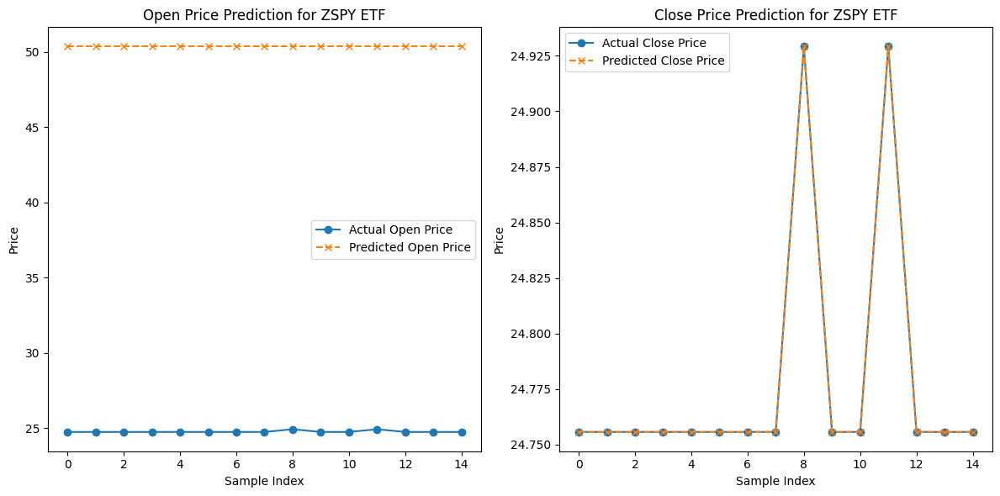

In [162]:
etf_symbol = 'ZSPY' 
etf_data = df_merged[df_merged['asset'] == etf_symbol]

random_samples = etf_data.sample(n=15, random_state=42)

X_test = random_samples[['lag_open', 'lag_close']]
y_test_open = random_samples['open']
y_test_close = random_samples['close']

y_pred_open = model_open.predict(X_test)
y_pred_close = model_close.predict(X_test)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(y_test_open.values, label='Actual Open Price', marker='o')
plt.plot(y_pred_open, label='Predicted Open Price', linestyle='--', marker='x')
plt.title(f'Open Price Prediction for {etf_symbol} ETF')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_test_close.values, label='Actual Close Price', marker='o')
plt.plot(y_pred_close, label='Predicted Close Price', linestyle='--', marker='x')
plt.title(f'Close Price Prediction for {etf_symbol} ETF')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()


In [171]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

def engineer_features_and_target(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Adds technical features and calculates the forward return target.
    horizon: number of days ahead to predict.
    """
    df = df.copy().sort_values('Date')
    
    # --- 1. Base Returns & Lags ---
    df['daily_return'] = df['close'].pct_change()
    df['lag_1_return'] = df['daily_return'].shift(1)
    df['lag_2_return'] = df['daily_return'].shift(2)
    df['lag_3_return'] = df['daily_return'].shift(3)
    
    # --- 2. Moving Averages (Momentum) ---
    df['sma_10'] = df['close'].rolling(window=10).mean()
    df['sma_21'] = df['close'].rolling(window=21).mean()
    # Distance from current price to SMA (normalized)
    df['dist_sma_10'] = (df['close'] - df['sma_10']) / df['sma_10']
    df['dist_sma_21'] = (df['close'] - df['sma_21']) / df['sma_21']
    
    # --- 3. Volatility ---
    df['volatility_21'] = df['daily_return'].rolling(window=21).std()
    
    # --- 4. Price Extremes ---
    df['high_low_spread'] = (df['high'] - df['low']) / df['open']
    
    # --- 5. TARGET VARIABLE ---
    # We want to predict the cumulative return 'horizon' days into the future.
    # Target = (Close_{t+horizon} - Close_t) / Close_t
    df['target_forward_return'] = df['close'].shift(-horizon) / df['close'] - 1
    
    return df



import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

def walk_forward_predictions(
    df_merged: pd.DataFrame, 
    business_days: pd.Series, 
    model_pipeline, 
    param_grid: dict,
    portfolios: dict,             # <-- NEW: The dictionary of dataframes loaded from Excel
    sheet_date_format: str = '%Y-%m-%d' # <-- NEW: Format to match your Excel sheet names
):
    predictions = []
    
    # Convert dates to datetime
    df_merged['Date'] = pd.to_datetime(df_merged['Date'])
    business_days = pd.to_datetime(business_days)
    
    # Ensure dates are datetime objects
    df_merged['Date'] = pd.to_datetime(df_merged['Date'])
    business_days = pd.to_datetime(business_days)
    
    # =========================================================================
    # NEW: CALCULATE START INDEX (3 YEARS FROM FIRST BUSINESS DAY)
    # =========================================================================
    start_date = business_days.iloc[0] + timedelta(days=365 * 3)
    initial_date = business_days[business_days <= start_date].iloc[-1]
    
    # Find the integer positional index safely, regardless of custom index type
    start_idx = np.where(business_days == initial_date)[0][0]
    # =========================================================================
    
    # Use your custom progress bar text, starting from start_idx up to the second-to-last day
    pbar = tqdm(
        range(start_idx, len(business_days) - 1), 
        desc='Portfolio optimization with month weight rebalancing'
    )
    
    for i in pbar:
        current_date = business_days.iloc[i]
        next_date = business_days.iloc[i + 1]
        
        # ==========================================
        # NEW: DYNAMIC ETF FILTERING
        # ==========================================
        # Convert timestamp to string to match Excel sheet names
        date_str = current_date.strftime(sheet_date_format) 
        
        # Safety check: ensure we have portfolio data for this date
        if date_str not in portfolios:
            print(f"Warning: Date {date_str} not found in portfolio sheets. Skipping.")
            continue
            
        # Get the filtered ETFs for this specific period
        etfs_list, mask = get_filtered_etfs(portfolios[date_str])
        # ==========================================
        
        # 1-year lookback window
        start_date = current_date - pd.DateOffset(years=1)
        window_df = df_merged[(df_merged['Date'] >= start_date) & (df_merged['Date'] <= current_date)]
        
        # Estimate trading days for the target horizon
        horizon = np.busday_count(current_date.date(), next_date.date())
        
        # Loop ONLY through the dynamically filtered list of ETFs
        for etf in etfs_list:
            etf_data = window_df[window_df['asset'] == etf].copy()
            
            if len(etf_data) < 100: 
                continue
                
            # Apply feature engineering (using the function defined in the previous step)
            etf_data = engineer_features_and_target(etf_data, horizon=horizon)
            
            current_day_features = etf_data.iloc[-1:] 
            train_data = etf_data.dropna()
            
            if len(train_data) < 50: 
                continue
                
            feature_cols = [
                'lag_1_return', 'lag_2_return', 'lag_3_return', 
                'dist_sma_10', 'dist_sma_21', 'volatility_21', 'high_low_spread'
            ]
            
            X_train = train_data[feature_cols]
            y_train = train_data['target_forward_return']
            X_predict = current_day_features[feature_cols]
            
            tscv = TimeSeriesSplit(n_splits=5)
            grid_search = GridSearchCV(
                estimator=model_pipeline,
                param_grid=param_grid,
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1
            )
            
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            pred_return = best_model.predict(X_predict)[0]
            
            predictions.append({
                'current_date': current_date,
                'next_date': next_date,
                'asset': etf,
                'predicted_period_return': pred_return,
                'cv_best_score_mae': -grid_search.best_score_, 
                'best_params': str(grid_search.best_params_)
            })

    return pd.DataFrame(predictions)

# ==========================================
# Example Execution
# ==========================================

# 1. Load your portfolios from Excel (creates a dict of DataFrames)
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
portfolios = pd.read_excel(Path.cwd().parent / "datasets" / "excel" / "last_filtered_weights.xlsx", sheet_name=None)

# Note: sheet_name=None reads ALL sheets into a dictionary. 
# If sheet_names_str is explicitly defined, you can keep your original code.

# 1. Define your pipeline (StandardScaler is crucial here!)
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

# 2. Define the hyperparameter grid you want to search
param_grid_ridge = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0]
}

# 3. Run the Walk-Forward Validation
# (Make sure 'first_business_days' is a pandas Series of datetime objects)
# 2. Run the updated pipeline
results_df = walk_forward_predictions(
    df_merged=df_merged,
    business_days=first_business_days,
    model_pipeline=pipeline_ridge,
    param_grid=param_grid_ridge,
    portfolios=portfolios,              # Pass the dictionary
    sheet_date_format='%Y-%m-%d'        # Adjust this if your sheet names format differently
)

print(results_df.head())


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_77704/1956960561.py:61: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_77704/1956960561.py:65: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

Portfolio optimization with month weight rebalancing: 100%|██████████| 83/83 [15:50<00:00, 11.45s/it]

  current_date  next_date asset  predicted_period_return  cv_best_score_mae  \
0   2019-01-02 2019-02-01  AAXJ                -0.015076           0.027827   
1   2019-01-02 2019-02-01  ACWI                -0.006986           0.026522   
2   2019-01-02 2019-02-01  ACWX                -0.010206           0.021903   
3   2019-01-02 2019-02-01   AGG                 0.001504           0.007532   
4   2019-01-02 2019-02-01  AMLP                 0.016837           0.052348   

               best_params  
0  {'model__alpha': 100.0}  
1  {'model__alpha': 100.0}  
2  {'model__alpha': 100.0}  
3  {'model__alpha': 100.0}  
4   {'model__alpha': 10.0}  


In [176]:
portfolios['2019-01-02'][portfolios['2019-01-02']['Value']==1]


,Key,Value
5,AAXJ,1
20,ACWI,1
21,ACWX,1
36,AGG,1
87,AMLP,1
...,...,...
3471,XLV,1
3473,XLY,1
3476,XME,1
3486,XOP,1


In [173]:
results_df[results_df['next_date']=='2019-02-01']


,current_date,next_date,asset,predicted_period_return,cv_best_score_mae,best_params
0,2019-01-02,2019-02-01,AAXJ,-0.015076,0.027827,{'model__alpha': 100.0}
1,2019-01-02,2019-02-01,ACWI,-0.006986,0.026522,{'model__alpha': 100.0}
2,2019-01-02,2019-02-01,ACWX,-0.010206,0.021903,{'model__alpha': 100.0}
3,2019-01-02,2019-02-01,AGG,0.001504,0.007532,{'model__alpha': 100.0}
4,2019-01-02,2019-02-01,AMLP,0.016837,0.052348,{'model__alpha': 10.0}
...,...,...,...,...,...,...
206,2019-01-02,2019-02-01,XLV,0.000248,0.036468,{'model__alpha': 100.0}
207,2019-01-02,2019-02-01,XLY,-0.004393,0.040860,{'model__alpha': 100.0}
208,2019-01-02,2019-02-01,XME,-0.011565,0.059347,{'model__alpha': 100.0}
209,2019-01-02,2019-02-01,XOP,0.000620,0.096661,{'model__alpha': 100.0}


In [165]:
from __future__ import annotations

from typing import Union, Optional, Literal
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from beartype import beartype

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


ModelName = Literal[
    "auto",
    "linear",
    "ridge",
    "lasso",
    "elasticnet",
    "random_forest",
    "gradient_boosting"
]


RET_LAGS = [1, 2, 3, 5, 10]
ROLL_WINDOWS = [5, 10, 20, 60]

RECURSIVE_FEATURES = (
    ["ret_1d"]
    + [f"ret_lag_{lag}" for lag in RET_LAGS]
    + [f"ret_mean_{w}" for w in ROLL_WINDOWS]
    + [f"ret_vol_{w}" for w in ROLL_WINDOWS]
    + [f"momentum_{w}" for w in ROLL_WINDOWS]
)


@beartype
def find_start_time(
    dates: pd.Series,
    day: pd.Timestamp,
    years: int = 1
) -> pd.Timestamp:
    dates = pd.to_datetime(dates).dropna().sort_values().reset_index(drop=True)
    day = pd.Timestamp(day)

    target = day - pd.DateOffset(years=years)
    idx = (dates - target).abs().idxmin()

    return pd.Timestamp(dates.loc[idx])


@beartype
def make_ohlcv_return_features(df_merged: pd.DataFrame) -> pd.DataFrame:
    df = df_merged.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values(["asset", "Date"]).reset_index(drop=True)

    result = []

    for asset, g in df.groupby("asset", sort=False):
        g = g.sort_values("Date").copy()

        # Main return
        g["ret_1d"] = g["close"].pct_change()

        # Lagged returns
        for lag in RET_LAGS:
            g[f"ret_lag_{lag}"] = g["ret_1d"].shift(lag)

        # Rolling return statistics
        for w in ROLL_WINDOWS:
            min_periods = max(2, w // 2)

            g[f"ret_mean_{w}"] = (
                g["ret_1d"]
                .rolling(window=w, min_periods=min_periods)
                .mean()
            )

            g[f"ret_vol_{w}"] = (
                g["ret_1d"]
                .rolling(window=w, min_periods=min_periods)
                .std()
            )

            g[f"momentum_{w}"] = g["close"].pct_change(w)

        # Target: next-day close-to-close return
        g["target_next_ret"] = g["ret_1d"].shift(-1)

        result.append(g)

    features = pd.concat(result, ignore_index=True)
    features = features.replace([np.inf, -np.inf], np.nan)

    return features


@beartype
def get_model_space(model_name: ModelName = "ridge") -> dict:
    model_space = {
        "linear": {
            "model": LinearRegression(),
            "params": {}
        },

        "ridge": {
            "model": Ridge(),
            "params": {
                "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0]
            }
        },

        "lasso": {
            "model": Lasso(max_iter=20_000),
            "params": {
                "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1]
            }
        },

        "elasticnet": {
            "model": ElasticNet(max_iter=20_000),
            "params": {
                "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1],
                "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
            }
        },

        "random_forest": {
            "model": RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            ),
            "params": {
                "model__n_estimators": [100, 200],
                "model__max_depth": [3, 5, 8, None],
                "model__min_samples_leaf": [3, 5, 10]
            }
        },

        "gradient_boosting": {
            "model": GradientBoostingRegressor(random_state=42),
            "params": {
                "model__n_estimators": [100, 200],
                "model__learning_rate": [0.01, 0.03, 0.05],
                "model__max_depth": [2, 3, 4]
            }
        }
    }

    if model_name == "auto":
        return model_space

    return {model_name: model_space[model_name]}


@beartype
def build_pipeline(model) -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ]
    )


@beartype
def fit_best_model_for_asset(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "target_next_ret",
    model_name: ModelName = "ridge",
    cv_splits: int = 5,
    min_train_rows: int = 120,
    scoring: str = "neg_mean_squared_error"
) -> Optional[dict]:

    data = train_df.copy()
    data = data.dropna(subset=[target_col])

    if len(data) < min_train_rows:
        return None

    X = data[feature_cols]
    y = data[target_col]

    model_space = get_model_space(model_name)

    best_result = None

    n_splits = min(cv_splits, max(2, len(data) // 40))

    for candidate_name, spec in model_space.items():
        pipe = build_pipeline(spec["model"])

        param_grid = spec["params"]
        if len(param_grid) == 0:
            param_grid = {}

        tscv = TimeSeriesSplit(n_splits=n_splits)

        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=tscv,
            scoring=scoring,
            n_jobs=-1,
            refit=True
        )

        search.fit(X, y)

        result = {
            "model_name": candidate_name,
            "best_estimator": search.best_estimator_,
            "best_params": search.best_params_,
            "cv_score": search.best_score_,
            "n_train": len(data)
        }

        if best_result is None or result["cv_score"] > best_result["cv_score"]:
            best_result = result

    return best_result


@beartype
def build_recursive_feature_row(ret_history: pd.Series) -> pd.DataFrame:
    r = pd.Series(ret_history).dropna().astype(float).values

    row = {}

    row["ret_1d"] = r[-1] if len(r) >= 1 else np.nan

    for lag in RET_LAGS:
        pos = -1 - lag
        row[f"ret_lag_{lag}"] = r[pos] if len(r) > lag else np.nan

    for w in ROLL_WINDOWS:
        x = r[-w:] if len(r) > 0 else np.array([])

        row[f"ret_mean_{w}"] = np.mean(x) if len(x) >= 2 else np.nan
        row[f"ret_vol_{w}"] = np.std(x, ddof=1) if len(x) >= 2 else np.nan
        row[f"momentum_{w}"] = np.prod(1 + x) - 1 if len(x) >= 2 else np.nan

    return pd.DataFrame([row])


@beartype
def get_actual_period_return(
    raw_asset_df: pd.DataFrame,
    current_date: pd.Timestamp,
    next_date: pd.Timestamp
) -> float:
    g = raw_asset_df.sort_values("Date").copy()

    before_current = g[g["Date"] <= current_date]
    before_next = g[g["Date"] <= next_date]

    if before_current.empty or before_next.empty:
        return np.nan

    close_current = before_current.iloc[-1]["close"]
    close_next = before_next.iloc[-1]["close"]

    if pd.isna(close_current) or pd.isna(close_next) or close_current == 0:
        return np.nan

    return close_next / close_current - 1


@beartype
def predict_asset_period_return(
    features_df: pd.DataFrame,
    raw_df: pd.DataFrame,
    asset: str,
    current_date: pd.Timestamp,
    next_date: pd.Timestamp,
    all_trading_dates: pd.Series,
    model_name: ModelName = "ridge",
    years: int = 1,
    cv_splits: int = 5,
    min_train_rows: int = 120,
    clip_daily_prediction: Optional[float] = 0.20
) -> Optional[dict]:

    current_date = pd.Timestamp(current_date)
    next_date = pd.Timestamp(next_date)

    asset_features = (
        features_df[features_df["asset"] == asset]
        .sort_values("Date")
        .copy()
    )

    raw_asset = (
        raw_df[raw_df["asset"] == asset]
        .sort_values("Date")
        .copy()
    )

    if asset_features.empty or raw_asset.empty:
        return None

    available_train_dates = asset_features[asset_features["Date"] < current_date]["Date"]

    if available_train_dates.empty:
        return None

    train_start = find_start_time(
        dates=available_train_dates,
        day=current_date,
        years=years
    )

    train_df = asset_features[
        (asset_features["Date"] >= train_start)
        & (asset_features["Date"] < current_date)
    ].copy()

    fit_result = fit_best_model_for_asset(
        train_df=train_df,
        feature_cols=RECURSIVE_FEATURES,
        target_col="target_next_ret",
        model_name=model_name,
        cv_splits=cv_splits,
        min_train_rows=min_train_rows
    )

    if fit_result is None:
        return None

    model = fit_result["best_estimator"]

    # Return history known at current_date
    known_prices = raw_asset[raw_asset["Date"] <= current_date].copy()
    known_returns = known_prices["close"].pct_change().dropna()

    if len(known_returns) < 20:
        return None

    horizon_dates = all_trading_dates[
        (all_trading_dates > current_date)
        & (all_trading_dates <= next_date)
    ].sort_values()

    # fallback for future period without trading dates in dataset
    if len(horizon_dates) == 0:
        horizon_dates = pd.Series(pd.bdate_range(current_date, next_date)[1:])

    daily_predictions = []

    ret_history = known_returns.copy()

    for forecast_date in horizon_dates:
        X_next = build_recursive_feature_row(ret_history)
        X_next = X_next[RECURSIVE_FEATURES]

        pred_ret = float(model.predict(X_next)[0])

        if clip_daily_prediction is not None:
            pred_ret = float(
                np.clip(
                    pred_ret,
                    -clip_daily_prediction,
                    clip_daily_prediction
                )
            )

        daily_predictions.append(pred_ret)

        ret_history = pd.concat(
            [
                ret_history,
                pd.Series([pred_ret], index=[forecast_date])
            ]
        )

    if len(daily_predictions) == 0:
        predicted_period_return = np.nan
    else:
        predicted_period_return = float(np.prod(1 + np.array(daily_predictions)) - 1)

    actual_period_return = get_actual_period_return(
        raw_asset_df=raw_asset,
        current_date=current_date,
        next_date=next_date
    )

    return {
        "rebalance_date": current_date,
        "next_rebalance_date": next_date,
        "asset": asset,
        "predicted_period_return": predicted_period_return,
        "actual_period_return": actual_period_return,
        "predicted_daily_returns": daily_predictions,
        "best_model": fit_result["model_name"],
        "best_params": fit_result["best_params"],
        "cv_score": fit_result["cv_score"],
        "n_train": fit_result["n_train"],
        "train_start": train_start
    }


@beartype
def predict_all_assets_for_rebalance_date(
    features_df: pd.DataFrame,
    raw_df: pd.DataFrame,
    first_business_days: pd.Series,
    current_date: pd.Timestamp,
    model_name: ModelName = "ridge",
    years: int = 1,
    cv_splits: int = 5,
    min_train_rows: int = 120,
    assets: Optional[list[str]] = None
) -> pd.DataFrame:

    fbd = pd.to_datetime(first_business_days).dropna().sort_values().reset_index(drop=True)

    current_date = pd.Timestamp(current_date)

    idx_arr = np.where(fbd.values == np.datetime64(current_date))[0]

    if len(idx_arr) == 0:
        idx = fbd.searchsorted(current_date, side="right") - 1
    else:
        idx = idx_arr[0]

    if idx < 0 or idx >= len(fbd) - 1:
        raise ValueError("current_date must have a next first-business-day date.")

    current_date = pd.Timestamp(fbd.iloc[idx])
    next_date = pd.Timestamp(fbd.iloc[idx + 1])

    all_trading_dates = (
        pd.to_datetime(raw_df["Date"])
        .dropna()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    if assets is None:
        assets = sorted(raw_df["asset"].dropna().unique().tolist())

    rows = []

    for asset in tqdm(assets, desc=f"Predicting {current_date.date()} -> {next_date.date()}"):
        result = predict_asset_period_return(
            features_df=features_df,
            raw_df=raw_df,
            asset=asset,
            current_date=current_date,
            next_date=next_date,
            all_trading_dates=all_trading_dates,
            model_name=model_name,
            years=years,
            cv_splits=cv_splits,
            min_train_rows=min_train_rows
        )

        if result is not None:
            rows.append(result)

    return pd.DataFrame(rows)


@beartype
def run_rolling_first_business_day_predictions(
    df_merged: pd.DataFrame,
    first_business_days: pd.Series,
    start_date: pd.Timestamp,
    model_name: ModelName = "ridge",
    years: int = 1,
    cv_splits: int = 5,
    min_train_rows: int = 120,
    assets: Optional[list[str]] = None
) -> pd.DataFrame:

    raw_df = df_merged.copy()
    raw_df["Date"] = pd.to_datetime(raw_df["Date"])

    features_df = make_ohlcv_return_features(raw_df)

    fbd = pd.to_datetime(first_business_days).dropna().sort_values().reset_index(drop=True)
    start_date = pd.Timestamp(start_date)

    start_idx = fbd.searchsorted(start_date, side="left")

    all_period_predictions = []

    for i in range(start_idx, len(fbd) - 1):
        current_date = pd.Timestamp(fbd.iloc[i])

        pred_df = predict_all_assets_for_rebalance_date(
            features_df=features_df,
            raw_df=raw_df,
            first_business_days=fbd,
            current_date=current_date,
            model_name=model_name,
            years=years,
            cv_splits=cv_splits,
            min_train_rows=min_train_rows,
            assets=assets
        )

        all_period_predictions.append(pred_df)

    if len(all_period_predictions) == 0:
        return pd.DataFrame()

    return pd.concat(all_period_predictions, ignore_index=True)


first_business_days = pd.to_datetime(first_business_days).dropna().sort_values().reset_index(drop=True)

start_date = first_business_days.iloc[0] + pd.DateOffset(years=3)

initial_date = first_business_days[first_business_days <= start_date].iloc[-1]

predictions_df = run_rolling_first_business_day_predictions(
    df_merged=df_merged,
    first_business_days=first_business_days,
    start_date=initial_date,
    model_name="ridge",       # "linear", "lasso", "elasticnet", "random_forest", "gradient_boosting", "auto"
    years=1,
    cv_splits=5,
    min_train_rows=120
)

predictions_df.head()


/Users/mac/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Predicting 2019-02-01 -> 2019-03-01:   0%|          | 0/3122 [00:00<?, ?it/s]/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value 

KeyboardInterrupt: 